# 04 Thinking In Langgraph
- 기획을 할때 어떻게 해야하는지
- 랭그래프 특성 어떤것이 있는지

In [79]:
from dotenv import load_dotenv
load_dotenv()

True

## Langchain의 Agent도 결국 작은 Graph다.

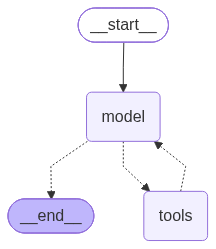

In [80]:
from langchain.agents import create_agent

# 샘플 Tool
def a():
    '''설명'''
    return 0

def b():
    '''설명'''
    return 1

# Langchain 의 Pre-built Agent
create_agent(model='openai:gpt-4.1-mini', tools=[a, b])

### Langgraph로 직접 만들기

In [81]:
# Tool
from langchain.tools import tool  # 데코레이터

@tool  # 이 함수는 단순 함수가 아닌 tool이다.
def add(a: int, b: int):
    '''
    `a` 와 `b`를 더한다.
    Args:
        a: first int
        b: second int
    '''
    return a + b


@tool
def multiply(a: int, b: int):
    '''
    `a` 와 `b`를 곱한다.
    Args:
        a: first int
        b: second int
    '''
    return a * b


@tool
def divide(a: int, b: int):
    '''
    `a` 와 `b`를 나눈다.
    Args:
        a: first int
        b: second int
    '''
    return a / b


tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}  # dict comprehension -> for + 딕셔너리 생성 한번에!
tools_by_name

{'add': StructuredTool(name='add', description='`a` 와 `b`를 더한다.\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x0000018DA52778A0>),
 'multiply': StructuredTool(name='multiply', description='`a` 와 `b`를 곱한다.\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000018DA5277A00>),
 'divide': StructuredTool(name='divide', description='`a` 와 `b`를 나눈다.\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x0000018DA5277D70>)}

In [82]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('openai:gpt-4.1-mini', temperature=0)
llm_with_tools = llm.bind_tools(tools)

# 차이 확인
print(llm.invoke('1+1*2/4'))  # 답변(content)생성, tool_calls 비어있음

# 경우에 따라서 tool 사용이 필요하다 판단하면, 답변 없음, 대신 tool_calls 항목이 있음
llm_with_tools.invoke('1+1*3/4')

'''
tool_calls = [
    {'name': 'multiply', 'args': {'a': 1, 'b': 3}, 'id': 'call_Mqz8JCrZAqXEoCFVdSsQ8uuA', 'type': 'tool_call'}, 
    {'name': 'divide', 'args': {'a': 3, 'b': 4}, 'id': 'call_J4atsqL9OKkUoLM2Sy7vUriE', 'type': 'tool_call'}
]
'''
# 결론
# bind_tools() 된 llm 은, 
# 1. tool사용이 필요하다 판단하면, 본인이 가지고 있는 tool 목록 확인 -> 계획만 짜 놓음 (tool 실행 아님)
# 2. tool 사용이 필요하지 않다 판단하면, 그냥 일반 llm 처럼 동작

llm_with_tools.invoke('넌 누구니')


content="Let's solve the expression step-by-step:\n\nExpression: \\(1 + 1 \\times 2 \\div 4\\)\n\nAccording to the order of operations (PEMDAS/BODMAS):\n\n1. Multiplication and division from left to right:\n   - \\(1 \\times 2 = 2\\)\n   - \\(2 \\div 4 = 0.5\\)\n\n2. Addition:\n   - \\(1 + 0.5 = 1.5\\)\n\n**Answer:** \\(1.5\\)" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 14, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c721606bd7', 'id': 'chatcmpl-EJtkybR2PPAFbTBu5ocPtM8D8JAC9', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_

AIMessage(content='안녕하세요! 저는 OpenAI가 만든 AI 언어 모델인 ChatGPT입니다. 질문에 답하거나 대화를 나누고, 다양한 주제에 대해 도움을 드릴 수 있어요. 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 152, 'total_tokens': 201, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_8b33040d7b', 'id': 'chatcmpl-EJtl1sY49moEoxOqoK3h0xZeFpvZz', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0659e-5926-7121-9132-599dff32bcdc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 152, 'output_tokens': 49, 'total_tokens': 201, 'input_token_details': {'audio': 0, 'cache_rea

In [83]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

# 노드로 감싸서, 그래프로 조립.
def llm_call(state: MessagesState):
    '''llm call 이 만드는 messages 경우의 수
    1. 답변 생성
    2. tool 계획
    '''
    messages = [
        SystemMessage('너는 사칙연산을 도와주는 멋진 에이전트야.')
    ] + state['messages']

    result = llm_with_tools.invoke(messages)  # Tool 실행 계획
    return {'messages': result}  

In [84]:
def tool_call_node(state: MessagesState):
    '''실제 Tool을 실행하는 Node'''
    result = []
    for tool_call in state['messages'][-1].tool_calls:
        # 실제 Tool 고르기
        tool = tools_by_name[tool_call['name']]
        # Tool 실행하고 결과 관측
        obsevation = tool.invoke(tool_call['args'])
        # 모든 선택된 tool함수의 실행 결과를 모음
        result.append(ToolMessage(content=obsevation, tool_call_id=tool_call['id']))

    return {'messages': result}

In [85]:
# conditonal edge 를 위한 라우터

def answer_or_tool_router(state: MessagesState):
    '''답변 생성 vs Tool 호출'''
    # 마지막 메세지만 확인
    last_message = state['messages'][-1]

    # 마지막 메세지(llm 판단)에 tool_calls 항목이 있으면 tool 실행으로, 없으면 종료
    if last_message.tool_calls:
        return '도구실행'
    else:
        return '답변제출'

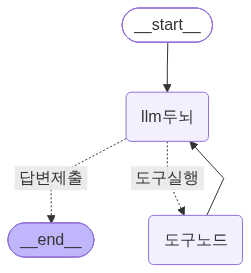

In [86]:
builder = StateGraph(MessagesState)
builder.add_node('llm두뇌', llm_call)
builder.add_node('도구노드', tool_call_node)

builder.add_edge(START, 'llm두뇌')
builder.add_conditional_edges(
    'llm두뇌',
    answer_or_tool_router,
    {
        '도구실행': '도구노드',
        '답변제출': END
    }
)
builder.add_edge('도구노드', 'llm두뇌')
graph = builder.compile()
graph

In [87]:
answer = graph.invoke({
    'messages': [HumanMessage('3 + 4 * 2 / 4')]
})

for m in answer['messages']:
    m.pretty_print()

================================ Human Message =================================

3 + 4 * 2 / 4
================================== Ai Message ==================================
Tool Calls:
  multiply (call_vc6pGkyymQZJGVj8dObFxKYC)
 Call ID: call_vc6pGkyymQZJGVj8dObFxKYC
  Args:
    a: 4
    b: 2
  divide (call_9PkqhLk0xccXggGgqdTifQmQ)
 Call ID: call_9PkqhLk0xccXggGgqdTifQmQ
  Args:
    a: 8
    b: 4
================================= Tool Message =================================

8
================================= Tool Message =================================

2.0
================================== Ai Message ==================================
Tool Calls:
  add (call_Bekw9Zn2fq6lbzJuE9A1Vn7A)
 Call ID: call_Bekw9Zn2fq6lbzJuE9A1Vn7A
  Args:
    a: 3
    b: 2
================================= Tool Message =================================

5
================================== Ai Message ==================================

3 + 4 * 2 / 4의 계산 결과는 5입니다.


## Node의 병렬 실행

- N8N은 기본적으로 여러노드를 동시에 연결해도 하나씩 실행됨
- Langgraph는 기본적으로 병렬 실행됨

In [93]:
class MyState(MessagesState):
    # messages: list 는 상속받아왔다!
    jpn: str
    eng: str
    chn: str

llm = init_chat_model('openai:gpt-4.1', temperature=1.3)

def jpn_node(state: MyState):
    prompt = '''
    너는 일본어 번역을 해주는 ai야.
    사용자의 입력을 일본 정서에 맞게 잘 번역해줘.
    '''
    result = llm.invoke([
        SystemMessage(prompt),
        state['messages'][-1]
    ])
    return {'jpn': result.content}

def eng_node(state: MyState):
    prompt = '''
    너는 영어 번역을 해주는 ai야.
    사용자의 입력을 미국 정서에 맞게 잘 번역해줘.
    '''
    result = llm.invoke([
        SystemMessage(prompt),
        state['messages'][-1]
    ])
    return {'eng': result.content}

def chn_node(state: MyState):
    prompt = '''
    너는 중국어 번역을 해주는 ai야.
    사용자의 입력을 중국 정서에 맞게 잘 번역해줘.
    '''
    result = llm.invoke([
        SystemMessage(prompt),
        state['messages'][-1]
    ])
    return {'chn': result.content}

def aggr_node(state: MyState):
    prompt = f'''
너는 다음 내용들을 잘 정리해서 보기 쉽게 만들어줘.
    
원문: {state['messages'][-1].content}
---
영어: {state['eng']}
---
일본어: {state['jpn']}
---
중국어: {state['chn']}
'''
    result = llm.invoke(prompt)  # AIMessage 저장
    return {'messages': [result]}

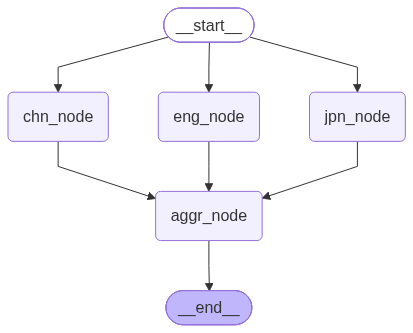

In [94]:
builder = StateGraph(MyState)
builder.add_node(eng_node)
builder.add_node(jpn_node)
builder.add_node(chn_node)
builder.add_node(aggr_node)
builder.add_edge(START, 'eng_node')
builder.add_edge(START, 'jpn_node')
builder.add_edge(START, 'chn_node')
builder.add_edge('eng_node', 'aggr_node')
builder.add_edge('chn_node', 'aggr_node')
builder.add_edge('jpn_node', 'aggr_node')
builder.add_edge('aggr_node', END)

graph = builder.compile()
graph

In [97]:
result = graph.invoke({
    'messages': [
        HumanMessage('안녕하세요, 노드크루에서 교육생 여러분께 Claude(Pro플랜) 1개월 구독을 지원할 예정입니다.')
    ]
})

In [98]:
from pprint import pprint
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

안녕하세요, 노드크루에서 교육생 여러분께 Claude(Pro플랜) 1개월 구독을 지원할 예정입니다.
================================== Ai Message ==================================

아래와 같이 표로 정리해드릴게요.

| 언어     | 내용                                                                                                                     |
|----------|------------------------------------------------------------------------------------------------------------------------|
| 한국어   | 안녕하세요, 노드크루에서 교육생 여러분께 Claude(Pro플랜) 1개월 구독을 지원할 예정입니다.                                 |
| 영어     | Hello! At Node Crew, we plan to provide all trainees with a one-month subscription to Claude (Pro Plan).               |
| 일본어   | こんにちは、ノードクルーからのお知らせです。受講生の皆さまに、Claude（プロプラン）の1か月間無料サブスクリプションを提供する予定です。 |
| 중국어   | 안녕하세요, 노드크루에서 교육생 여러분께 Claude（专业版）一个月订阅服务即将开放申请。                                     |

추가로, 보기 쉽게 각 언어별로 구분해서 안내하실 때 활용하실 수 있도록 나열 방식도 제공드립니다.

---

**한국어**  
안녕하세요, 노드